<a href="https://colab.research.google.com/github/AnuzzKhatri/US-Customer-Insight-EDA-Project/blob/main/Stats_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/US_Customer_Insights_Dataset.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 1. Understand Your Data (10 Marks)

In [ ]:
df

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103
...,...,...,...,...,...,...,...,...,...,...,...,...
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,8/24/23,2/29/24,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,4/13/23,12/31/24,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,7/3/22,9/21/23,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,9/19/23,12/29/23,494.17,580


In [ ]:
df.shape

(10675, 12)

In [ ]:
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Name,0
State,0
Education,0
Gender,0
Age,0
Married,0
NumPets,0
JoinDate,0
TransactionDate,0


In [ ]:
for col in df.columns:
    print(col, ":", df[col].nunique())

CustomerID : 1000
Name : 990
State : 10
Education : 5
Gender : 3
Age : 63
Married : 2
NumPets : 5
JoinDate : 731
TransactionDate : 1605
MonthlySpend : 9843
DaysSinceLastInteraction : 1605


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols)

Index(['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction'], dtype='object')


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married',
       'JoinDate', 'TransactionDate'],
      dtype='object')


In [ ]:
df.duplicated().sum()

np.int64(0)

## 2. Descriptive Statistics (15 Marks)

In [ ]:
df[['Age','MonthlySpend',
    'DaysSinceLastInteraction']].describe()

,Age,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000
mean,49.474567,331.610315,538.469883
std,18.221365,225.799253,398.766747
min,18.000000,3.890000,1.000000
25%,35.000000,165.495000,218.000000
50%,49.000000,282.110000,445.000000
75%,66.000000,443.255000,788.500000
max,80.000000,1740.420000,1791.000000


In [ ]:
print(df[['Age','MonthlySpend',
          'DaysSinceLastInteraction']].mean())

Age                          49.474567
MonthlySpend                331.610315
DaysSinceLastInteraction    538.469883
dtype: float64


In [ ]:
print(df[['Age',
          'MonthlySpend',
          'DaysSinceLastInteraction']].median())

Age                          49.00
MonthlySpend                282.11
DaysSinceLastInteraction    445.00
dtype: float64


In [ ]:
df[['Age','MonthlySpend',
    'DaysSinceLastInteraction']].median()

,0
Age,49.00
MonthlySpend,282.11
DaysSinceLastInteraction,445.00


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,3791
Non-Binary,3471
Female,3413


In [ ]:
print(df['Gender'].mode())

0    Male
Name: Gender, dtype: object


In [ ]:
df['Education'].value_counts()

,count
Education,
Master,2269
Associate,2153
Bachelor,2127
High School,2120
PhD,2006


In [ ]:
print(df['Education'].mode())

0    Master
Name: Education, dtype: object


In [ ]:
df['Married'].value_counts()

,count
Married,
No,5583
Yes,5092


In [ ]:
print(df['Married'].mode())

0    No
Name: Married, dtype: object


## 3. Data Visualization (15 Marks)

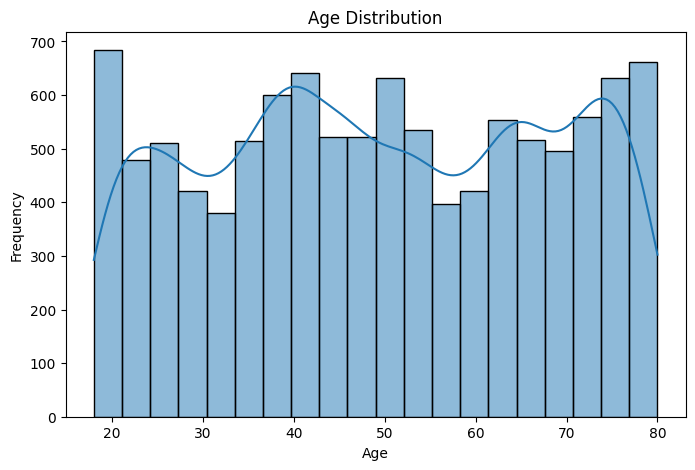

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'],
             bins=20,kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

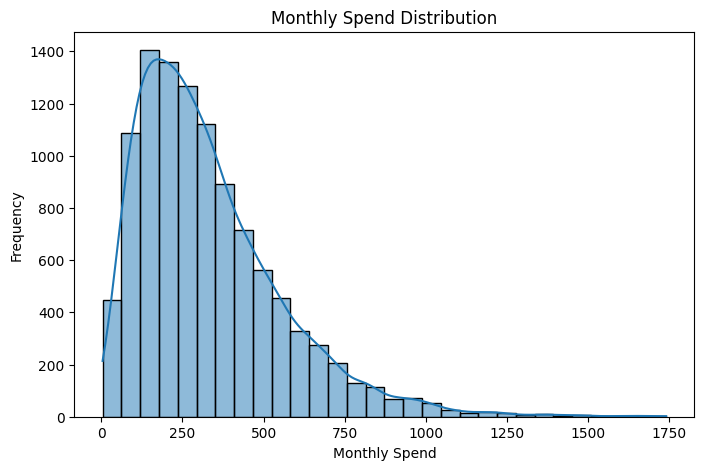

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlySpend'],
             bins=30,kde=True)
plt.title("Monthly Spend Distribution")
plt.xlabel("Monthly Spend")
plt.ylabel("Frequency")
plt.show()

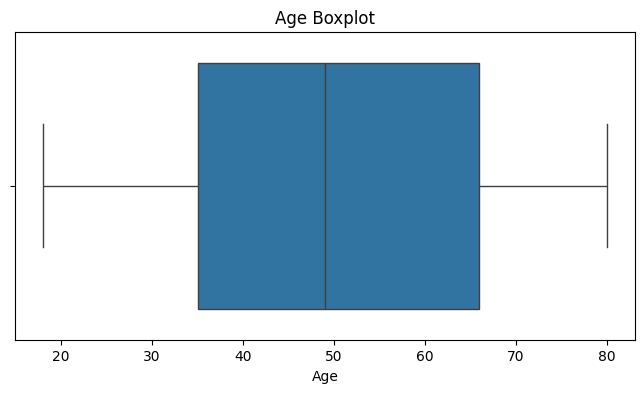

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'])
plt.title("Age Boxplot")
plt.show()

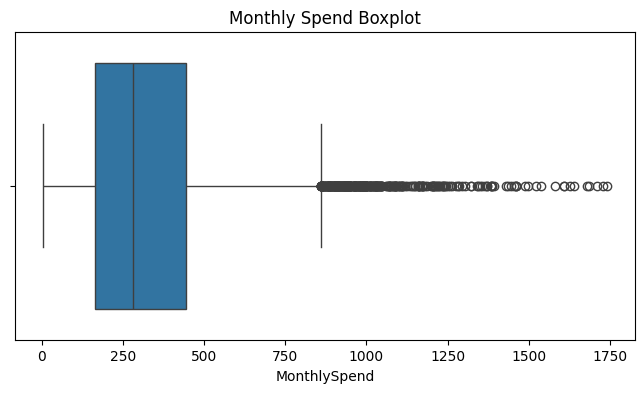

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['MonthlySpend'])
plt.title("Monthly Spend Boxplot")
plt.show()

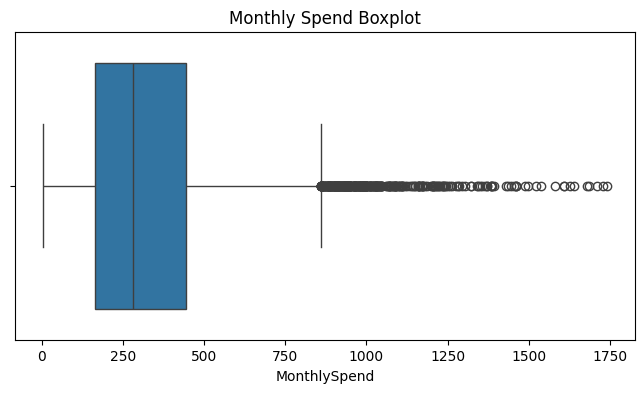

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['MonthlySpend'])
plt.title("Monthly Spend Boxplot")
plt.show()

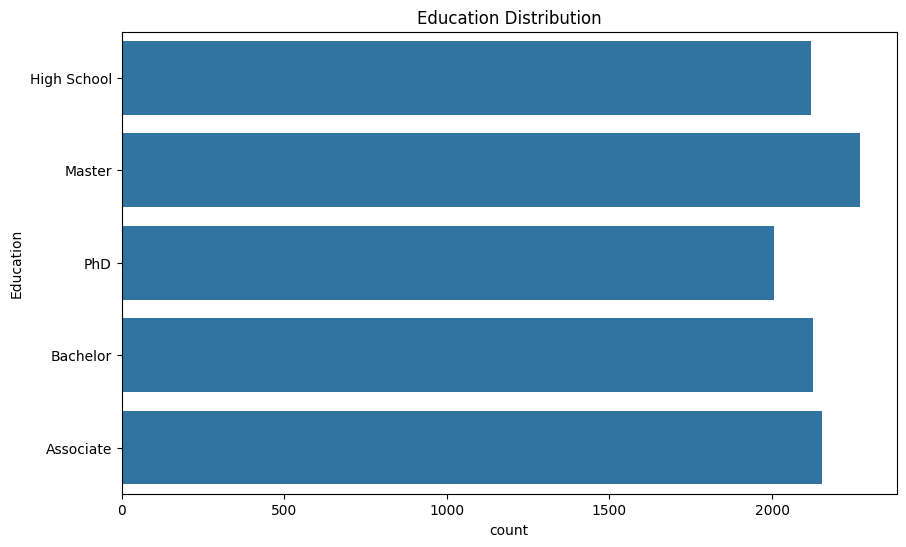

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(y='Education',data=df)
plt.title("Education Distribution")
plt.show()

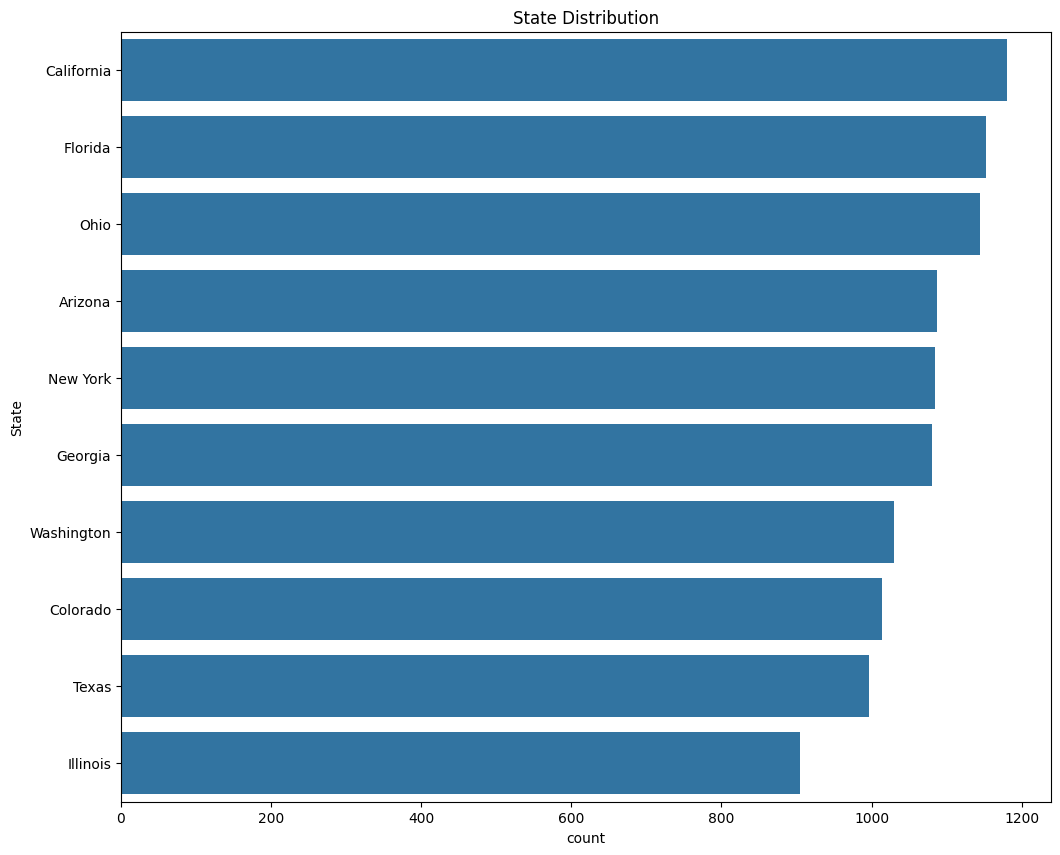

In [ ]:
plt.figure(figsize=(12,10))
sns.countplot(y='State',
              data=df,
              order=df['State'].value_counts().index)
plt.title("State Distribution")
plt.show()

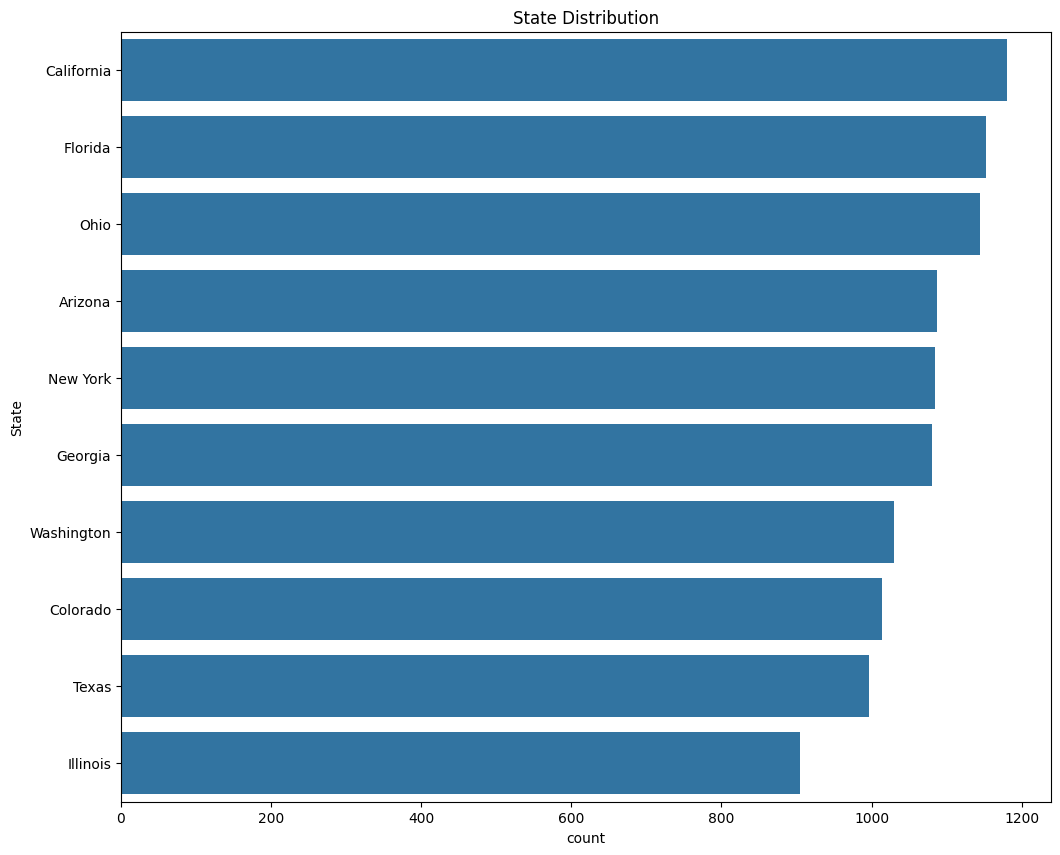

In [ ]:
plt.figure(figsize=(12,10))
sns.countplot(y='State',
              data=df,
              order=df['State'].value_counts().index)
plt.title("State Distribution")
plt.show()

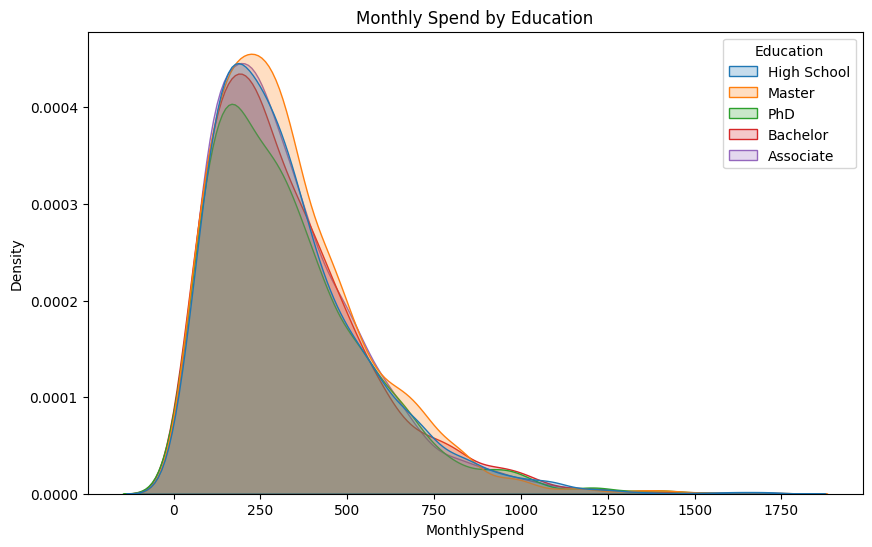

In [ ]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='MonthlySpend',hue='Education',fill=True)
plt.title("Monthly Spend by Education")
plt.show()

## 4. Bivariate Analysis (15 Marks)

In [ ]:
corr = df[['Age','NumPets','MonthlySpend','DaysSinceLastInteraction']].corr()
print(corr)

                               Age   NumPets  MonthlySpend  \
Age                       1.000000 -0.023035     -0.012323   
NumPets                  -0.023035  1.000000      0.020647   
MonthlySpend             -0.012323  0.020647      1.000000   
DaysSinceLastInteraction -0.003970 -0.055227      0.006081   

                          DaysSinceLastInteraction  
Age                                      -0.003970  
NumPets                                  -0.055227  
MonthlySpend                              0.006081  
DaysSinceLastInteraction                  1.000000  


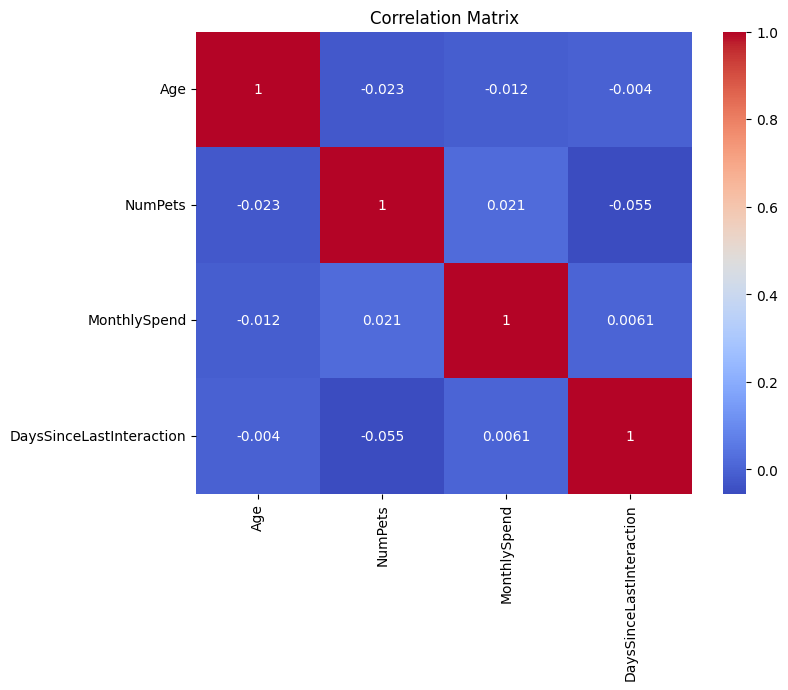

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 5. Hypothesis Formulation (10 Marks)

In [ ]:
cross_tab = pd.crosstab(df['Gender'],df['Married'])
print(cross_tab)

Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577


In [ ]:
gender_spend = df.groupby('Gender')['MonthlySpend'].mean()
print(gender_spend)

Gender
Female        331.361310
Male          333.174068
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


In [ ]:
edu_spend = df.groupby('Education')['MonthlySpend'].mean()
print(edu_spend)

Education
Associate      327.884408
Bachelor       331.884753
High School    332.215712
Master         334.252305
PhD            331.690090
Name: MonthlySpend, dtype: float64


In [ ]:
state_spend = df.groupby('State')['MonthlySpend'].mean()
print(state_spend)

State
Arizona       341.489135
California    339.183492
Colorado      323.083462
Florida       327.696892
Georgia       328.354648
Illinois      332.589591
New York      332.151244
Ohio          340.187860
Texas         319.506770
Washington    329.444078
Name: MonthlySpend, dtype: float64


## 6. Hypothesis Testing (20 Marks)

In [ ]:
male_spend = df[df['Gender']=='Male']['MonthlySpend']

female_spend = df[df['Gender']=='Female']['MonthlySpend']

t_stat,p_val = ttest_ind(male_spend,female_spend)

print("T Statistic:",t_stat)
print("P Value:",p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

T Statistic: 0.3391730320232445
P Value: 0.7344892727022859
Fail to Reject H0


In [ ]:
groups = []

for edu in df['Education'].unique():
  groups.append(df[df['Education']==edu]['MonthlySpend'])

f_stat,p_val = f_oneway(*groups)

print("F Statistic:",f_stat)
print("P Value:",p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F Statistic: 0.22880668673709162
P Value: 0.922359467759936
Fail to Reject H0


In [ ]:
contingency_table = pd.crosstab(df['Married'],df['NumPets'])

chi2,p_val,dof,expected = chi2_contingency(contingency_table)

print("Chi Square:",chi2)
print("P Value:",p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Chi Square: 177.63953668537033
P Value: 2.3957232932397494e-37
Reject H0


In [ ]:
corr,p_val = pearsonr(df['Age'],df['DaysSinceLastInteraction'])

print("Correlation:",corr)
print("P Value:",p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Correlation: -0.003970230104955049
P Value: 0.681690543730101
Fail to Reject H0


In [ ]:
groups = []

for state in df['State'].unique():
  groups.append(df[df['State']==state]['MonthlySpend'])

f_stat,p_val = f_oneway(*groups)

print("F Statistic:",f_stat)
print("P Value:",p_val)

if p_val < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

F Statistic: 1.1178423640877178
P Value: 0.34571886479238273
Fail to Reject H0


## 7. Business Insights & Recommendations (15 Marks)

In [ ]:
top_states = df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False)
print(top_states.head(10))

State
Arizona       341.489135
Ohio          340.187860
California    339.183492
Illinois      332.589591
New York      332.151244
Washington    329.444078
Georgia       328.354648
Florida       327.696892
Colorado      323.083462
Texas         319.506770
Name: MonthlySpend, dtype: float64


In [ ]:
top_edu = df.groupby(
    'Education')[
        'MonthlySpend'].mean().sort_values(ascending=False)
print(top_edu)

Education
Master         334.252305
High School    332.215712
Bachelor       331.884753
PhD            331.690090
Associate      327.884408
Name: MonthlySpend, dtype: float64


In [ ]:
df['CustomerSegment'] = pd.qcut(df['MonthlySpend'],q=3,labels=['Low','Medium','High'])
print(df['CustomerSegment'].value_counts())

CustomerSegment
Medium    3559
Low       3558
High      3558
Name: count, dtype: int64


### Business Insights & Recommendations

1. **High-spending customers contribute a significant portion of total revenue**, making them the most valuable customer segment.

   * **Recommendation:** Introduce VIP memberships, exclusive rewards, and premium services to improve retention.

2. **Medium-spending customers represent the greatest growth opportunity** and can potentially be converted into high-value customers.

   * **Recommendation:** Use personalized offers, discounts, and upselling strategies to increase their spending.

3. **Top-performing states generate higher average revenue**, indicating stronger market potential in certain regions.

   * **Recommendation:** Focus marketing efforts and promotional campaigns on these high-performing states.

4. **Education level shows only minor differences in spending behavior**, suggesting it is not a strong predictor of customer value.

   * **Recommendation:** Use education as a secondary segmentation factor rather than a primary targeting criterion.

5. **Premium customers have strong potential for cross-selling and upselling opportunities.**

   * **Recommendation:** Recommend complementary products, premium bundles, and subscription-based services.

6. **Demographic factors such as gender, age, and state have limited influence on spending patterns.**

   * **Recommendation:** Prioritize customer behavior, purchase history, and engagement metrics over demographic attributes.

7. **Behavioral segmentation is the most effective strategy for customer targeting and retention.**

   * **Recommendation:** Build data-driven marketing campaigns based on spending habits, interaction frequency, and customer engagement levels to maximize revenue and customer lifetime value.

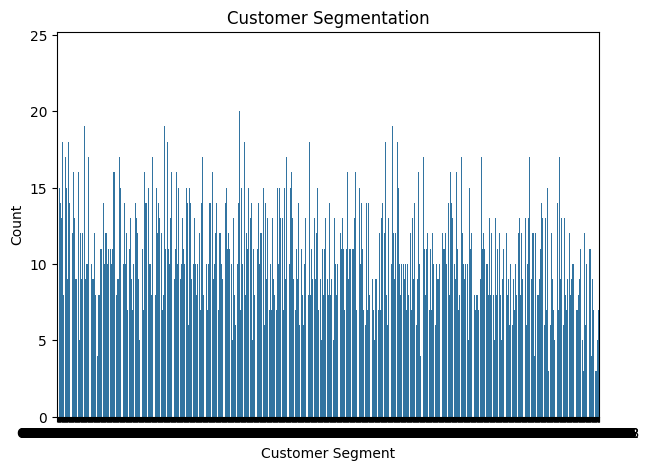

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='CustomerID', data=df)
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.title("Customer Segmentation")
plt.show()

In [ ]:
df.to_csv("Customer_Insights_Final.csv",index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


The analysis examined customer demographics, spending behavior, engagement patterns, and lifestyle factors. Statistical testing revealed that gender, education, age, and state do not significantly influence spending behavior. However, marital status and pet ownership exhibit a significant association. The customer base demonstrates highly skewed spending patterns, indicating the presence of premium-value customers. Businesses should prioritize behavioral segmentation and engagement-based marketing strategies over demographic targeting.